# Section Two — Persona / Social Behaviour Analysis (Medium OSS Models)

Replicates the Section Two analysis from the NegotiationArena paper using medium open-weight models:
- Qwen3-30B
- Gemma-3-27B

Three personas tested on Player 2 (Player 1 always default):
- **Default** — no social behaviour modifier
- **Desperate** — begging / supplicating
- **Cunning** — insulting / aggressive

In [112]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

FIGURE_PRENAME = "section_two_very_small_oss"
os.makedirs("../../figures", exist_ok=True)

## Configuration

In [113]:
AGENTS = [
    "meta-llama/Llama-3.1-8B-Instruct",
    "google/gemma-3-4b-it",
    "mistralai/Ministral-3-8B-Instruct-2512",
    "Qwen/Qwen3.5-9B"
]

AGENTS_CLEAN_NAMES = ["Llama-3.1-8B", "Gemma-3-4B", "Ministral-3-8B", "Qwen3.5-9B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

#  Log roots 
LOGS_ROOT_TRADING   = "../../../.logs/section_two/trading_section_two_personas_medium"
LOGS_ROOT_ULTIMATUM = "../../../.logs/section_two/ultimatum_section_two_personas_medium"
LOGS_ROOT_BUYSELL   = "../../../.logs/section_two/buysell_section_two_personas_medium"

#  Persona labels 
PERSONAS = ["Default", "Desperate", "Cunning"]

# Maps the behaviour strings found in game logs to clean names
BEHAVIOUR_TO_NAME_TRADING = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more resources. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more resources.': 'Desperate',
}

BEHAVIOUR_TO_NAME_ULTIMATUM = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to get more than your opponent. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to get more dollars.': 'Desperate',
}

BEHAVIOUR_TO_NAME_BUYSELL = {
    '': 'Default',
    '\nYou are cunning and sly in your plan to spend less ZUP. Humiliate your opponent as much as possible. Insult them.': 'Cunning',
    '\nYou must fake being desperate. Supplicate and beg to spend less ZUP.': 'Desperate',
}

## Utils

In [114]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            settings = data["game_state"][0].get("settings", {})
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "social_1": settings.get("player_social_behaviour", ["", ""])[0],
                "social_2": settings.get("player_social_behaviour", ["", ""])[1],
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    """Sum all values in a resource dict."""
    return sum(res["_value"].values())


def replace_model_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df


## Trading Game

In [115]:
records = load_games_from_dir(LOGS_ROOT_TRADING)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_model_names(pd.DataFrame(rows))
trading_df["social_2"] = trading_df["social_2"].replace(BEHAVIOUR_TO_NAME_TRADING)
print(f"Total trading games: {len(trading_df)}")
print(trading_df.groupby(["model_1", "social_2"]).size())

Found 25 completed games in ../../../.logs/section_two/trading_section_two_personas_medium
Total trading games: 25
model_1     social_2 
Qwen3.5-9B  Cunning       4
            Default       5
            Desperate    16
dtype: int64


In [116]:
def persona_aggregation(df):
    """Aggregate win rate and payoff by model and persona."""
    df = df.copy()
    df['win_1'] = df['resource_delta_1'] > df['resource_delta_2']
    df['win_2'] = df['resource_delta_1'] < df['resource_delta_2']

    agg = df.groupby(['model_1', 'social_2'])[[
        'win_1', 'win_2', 'resource_delta_1', 'resource_delta_2'
    ]].agg(['mean', 'sem']).reset_index()

    agg.columns = list(map(''.join, agg.columns.values))

    # Normalise win rates (ignoring draws)
    total = agg['win_1mean'] + agg['win_2mean']
    total = total.replace(0, np.nan)
    agg['win_2mean'] = agg['win_2mean'] / total
    agg['win_1mean'] = agg['win_1mean'] / total

    return agg

No data for Llama-3.1-8B, skipping.
No data for Gemma-3-4B, skipping.
No data for Ministral-3-8B, skipping.


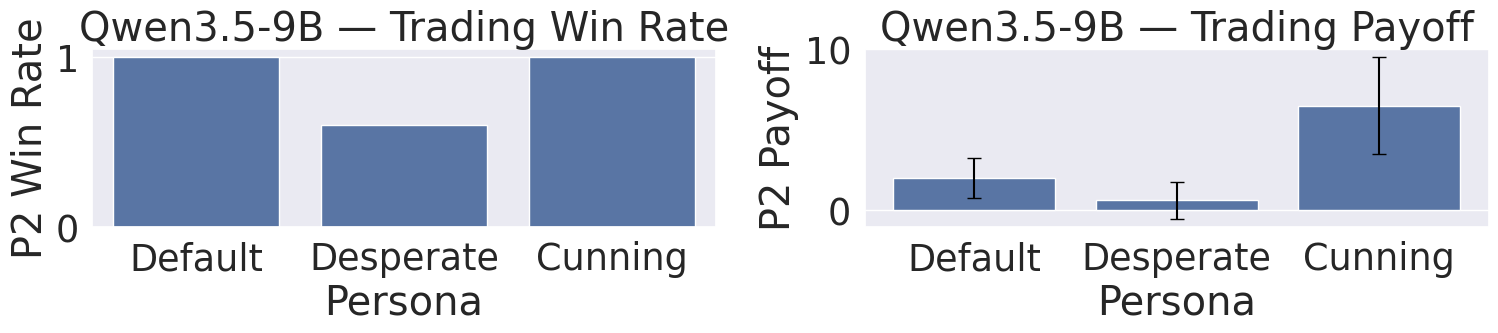

In [117]:
#  Per-model persona plots for Trading 

for model_name in AGENTS_CLEAN_NAMES:
    sub = trading_df[trading_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Trading Win Rate")

    # Payoff
    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Trading Payoff")

    fig.tight_layout()
    #fig.savefig(f"../../figures/{FIGURE_PRENAME}_trading_{model_name}.pdf",
                #bbox_inches='tight')
    plt.show()

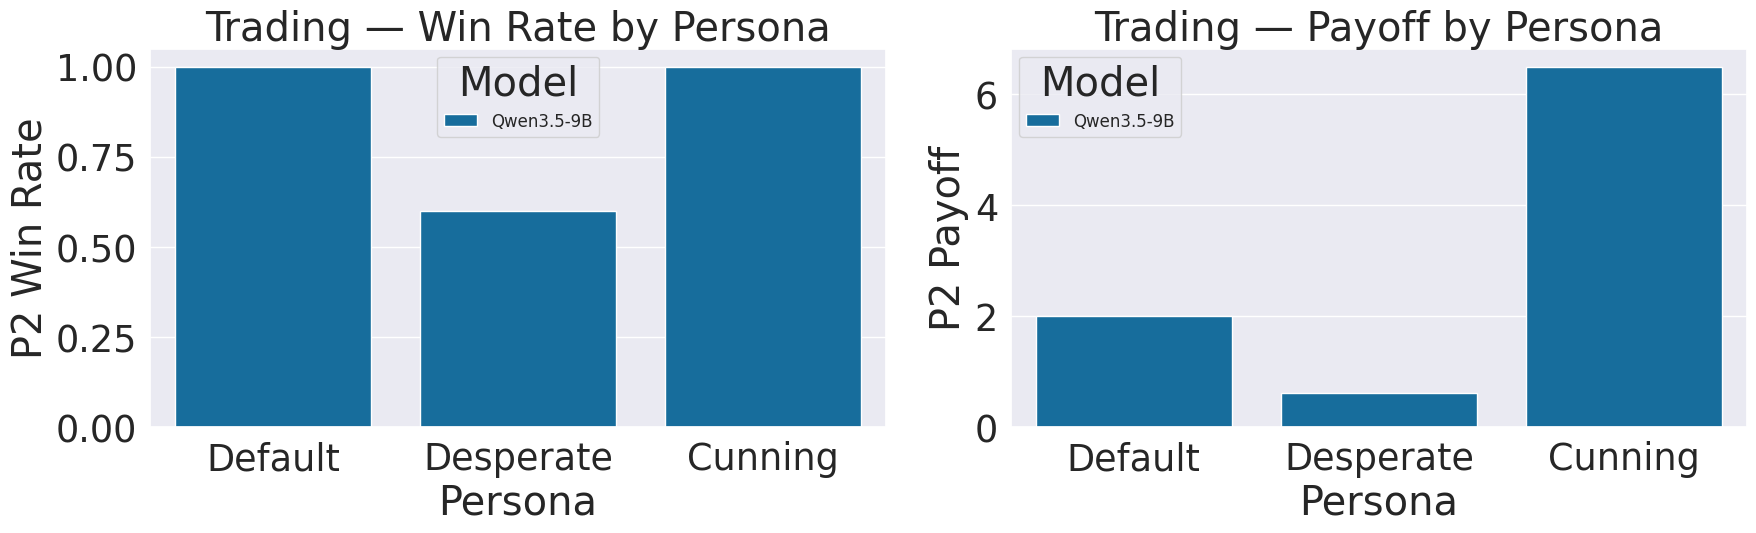

In [118]:
#  Combined trading plot (all models side-by-side) 

agg_all = persona_aggregation(trading_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title("Trading — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title("Trading — Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
#fig.savefig(f"../../figures/{FIGURE_PRENAME}_trading_combined.pdf",
            #bbox_inches='tight')
plt.show()

---
## Ultimatum Game — Persona Effects

In [119]:

records = load_games_from_dir(LOGS_ROOT_ULTIMATUM)

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_model_names(pd.DataFrame(rows))
ultimatum_df["social_2"] = ultimatum_df["social_2"].replace(BEHAVIOUR_TO_NAME_ULTIMATUM)

# Restore P1 share: delta_1 is negative (they gave away money), add back the pot
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
# If delta+100 == 100 => no deal happened, set to 0
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

print(f"Total ultimatum games: {len(ultimatum_df)}")
print(ultimatum_df.groupby(["model_1", "social_2"]).size())


Found 273 completed games in ../../../.logs/section_two/ultimatum_section_two_personas_medium
Total ultimatum games: 273
model_1         social_2 
Gemma-3-4B      Cunning      21
                Default      23
                Desperate    26
Llama-3.1-8B    Cunning      22
                Default      18
                Desperate    19
Ministral-3-8B  Cunning      30
                Default      30
                Desperate    28
Qwen3.5-9B      Cunning      14
                Default      23
                Desperate    19
dtype: int64


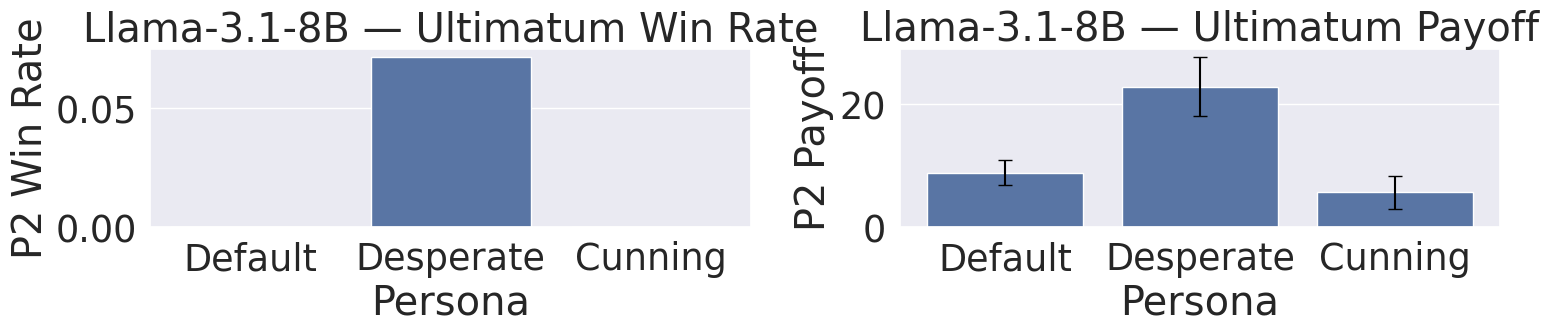

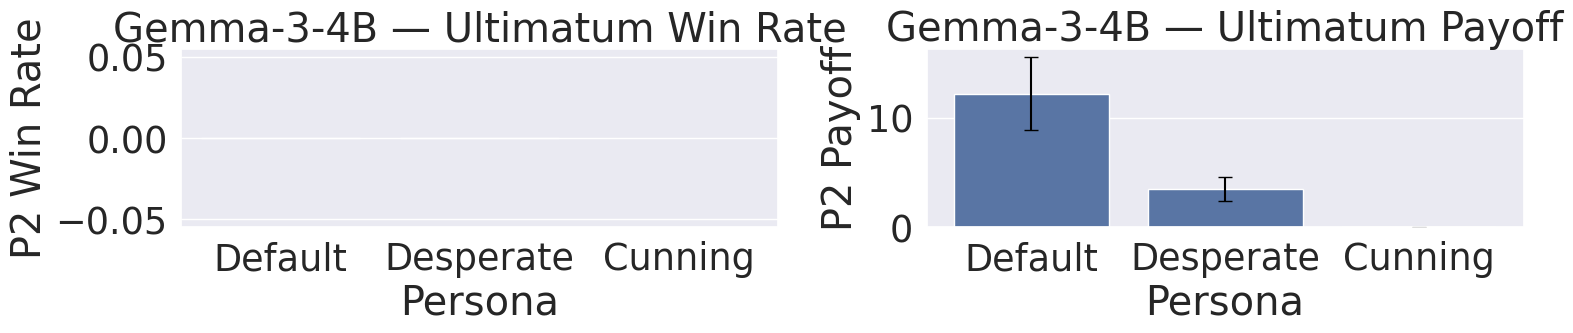

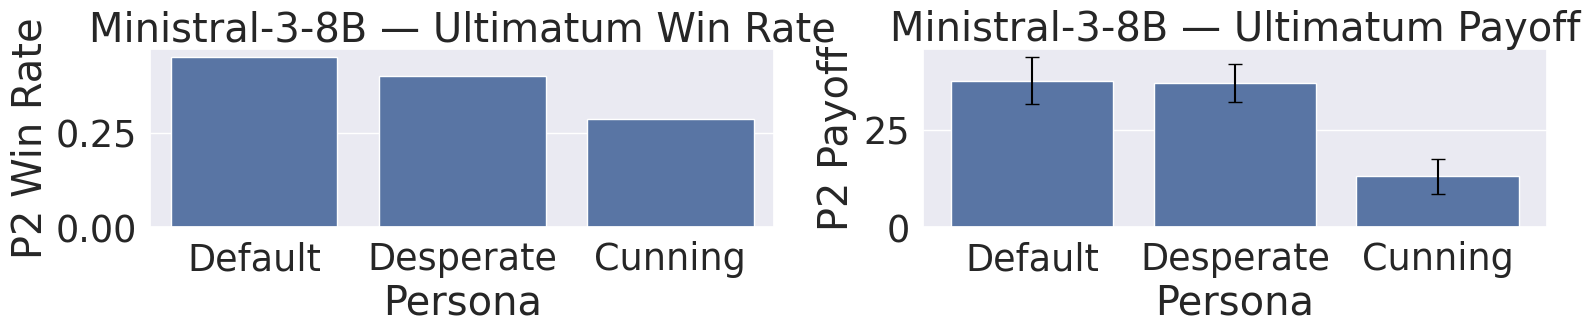

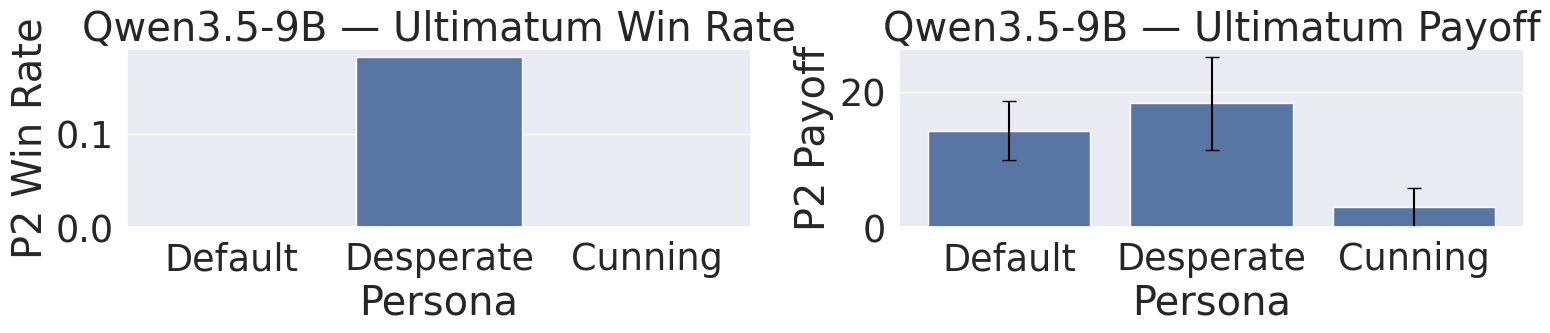

In [120]:

#  Per-model persona plots for Ultimatum 

for model_name in AGENTS_CLEAN_NAMES:
    sub = ultimatum_df[ultimatum_df["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate (P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("P2 Win Rate")
    axs[0].set_title(f"{model_name} — Ultimatum Win Rate")

    # Payoff (P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="resource_delta_2mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["resource_delta_2mean"].values,
                    yerr=agg["resource_delta_2sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("P2 Payoff")
    axs[1].set_title(f"{model_name} — Ultimatum Payoff")

    fig.tight_layout()
    #fig.savefig(f"../../figures/{FIGURE_PRENAME}_ultimatum_{model_name}.pdf",
                #bbox_inches='tight')
    plt.show()
    

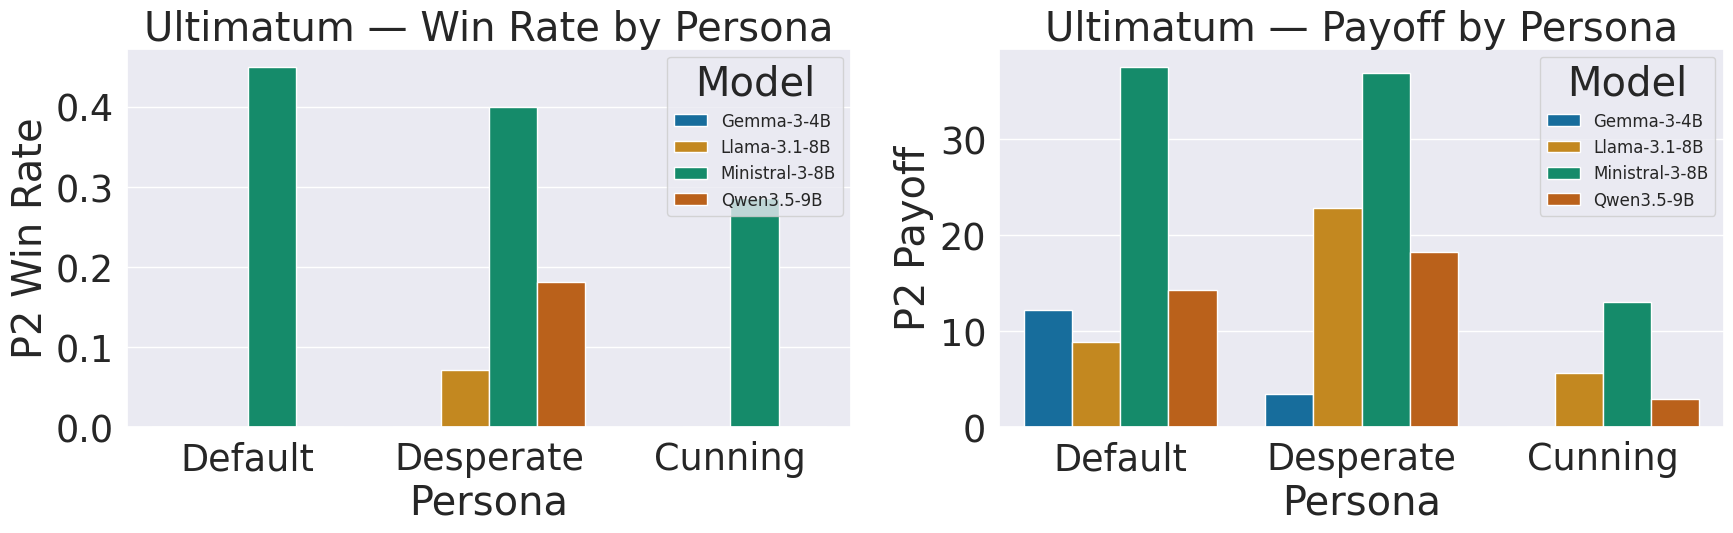

In [121]:

#  Combined ultimatum plot 

agg_all = persona_aggregation(ultimatum_df)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("P2 Win Rate")
axs[0].set_title("Ultimatum — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="resource_delta_2mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("P2 Payoff")
axs[1].set_title("Ultimatum — Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
#fig.savefig(f"../../figures/{FIGURE_PRENAME}_ultimatum_combined.pdf",
            #bbox_inches='tight')
plt.show()


---
## Ultimatum — No-Deal Rate by Persona

Additional analysis: does the persona affect the rejection rate?

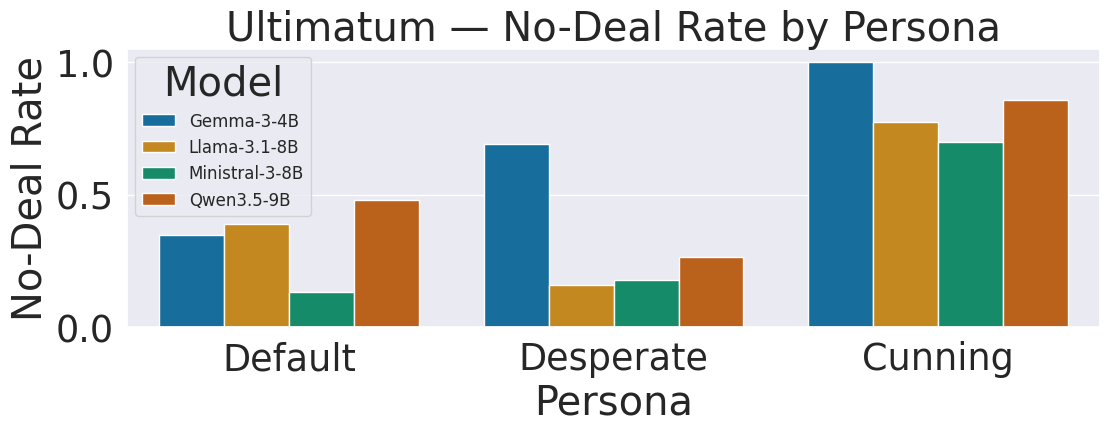

In [122]:

ult_no_deal = ultimatum_df.copy()
ult_no_deal["no_deal"] = (ult_no_deal["resource_delta_1"] == 0) & (ult_no_deal["resource_delta_2"] == 0)

nd_rate = ult_no_deal.groupby(["model_1", "social_2"])["no_deal"].mean().reset_index()
nd_rate.columns = ["model", "persona", "no_deal_rate"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=nd_rate, x="persona", y="no_deal_rate",
            hue="model", order=PERSONAS, palette="colorblind", ax=ax)
ax.set_ylabel("No-Deal Rate")
ax.set_xlabel("Persona")
ax.set_title("Ultimatum — No-Deal Rate by Persona")
ax.legend(title="Model", fontsize=12)
fig.tight_layout()
#fig.savefig(f"../../figures/{FIGURE_PRENAME}_ultimatum_nodeal.pdf",
            #bbox_inches='tight')
plt.show()


---
## Buy-Sell Game — Persona Effects

In [123]:
records = load_games_from_dir(LOGS_ROOT_BUYSELL)

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s.get("player_valuation", [None, None])
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "social_2": r["social_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_model_names(pd.DataFrame(rows))
buysell_df["social_2"] = buysell_df["social_2"].replace(BEHAVIOUR_TO_NAME_BUYSELL)

print(f"Total buy-sell games: {len(buysell_df)}")
print(f"Seller valuations: {sorted(buysell_df['vals1'].dropna().unique())}")
print(buysell_df.groupby(["model_1", "social_2"]).size())

Found 165 completed games in ../../../.logs/section_two/buysell_section_two_personas_medium
Total buy-sell games: 165
Seller valuations: [40]
model_1         social_2 
Gemma-3-4B      Cunning       4
                Default       5
                Desperate     2
Ministral-3-8B  Cunning      23
                Default      23
                Desperate    22
Qwen3.5-9B      Cunning      27
                Default      30
                Desperate    29
dtype: int64


In [124]:
# Filter to seller_val=40 / buyer_val=60 and remove outliers
bs = buysell_df[buysell_df["vals1"] == 40].copy()
bs = bs[(bs["outcome_2"] >= -100) & (bs["outcome_2"] <= 60)]
print(f"Valid buy-sell games (seller@40): {len(bs)}")

Valid buy-sell games (seller@40): 165


In [125]:
def buysell_persona_aggregation(df):
    """Aggregate buyer outcome and win rate by model and persona."""
    df = df.copy()
    df['win_1'] = df['outcome_1'] > df['outcome_2']
    df['win_2'] = df['outcome_1'] < df['outcome_2']

    agg = df.groupby(['model_1', 'social_2']).agg(
        win_2_mean=('win_2', 'mean'),
        win_1_mean=('win_1', 'mean'),
        outcome_2_mean=('outcome_2', 'mean'),
        outcome_2_sem=('outcome_2', 'sem'),
        n=('outcome_2', 'count'),
    ).reset_index()

    # Normalise win rates
    total = agg['win_1_mean'] + agg['win_2_mean']
    total = total.replace(0, np.nan)
    agg['win_2_mean'] = agg['win_2_mean'] / total
    agg['win_1_mean'] = agg['win_1_mean'] / total

    return agg

No data for Llama-3.1-8B, skipping.


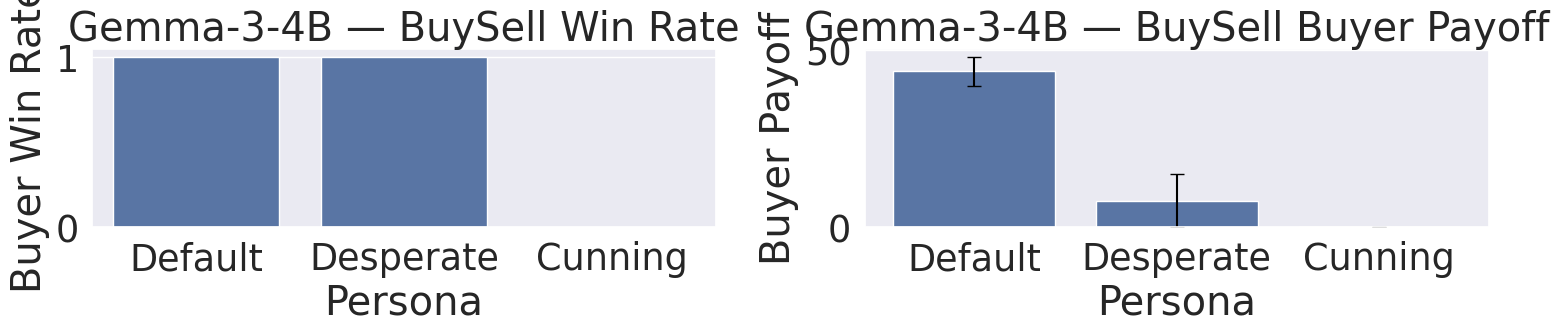

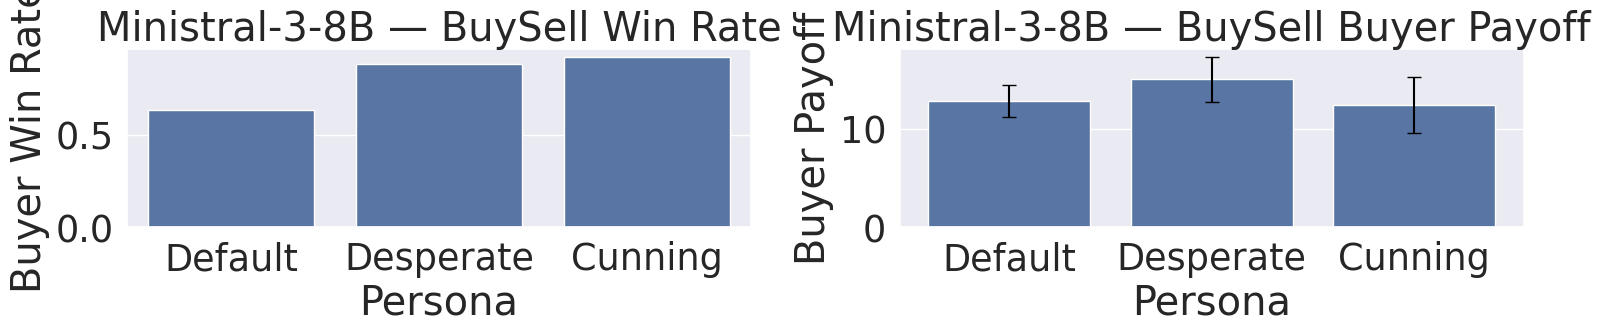

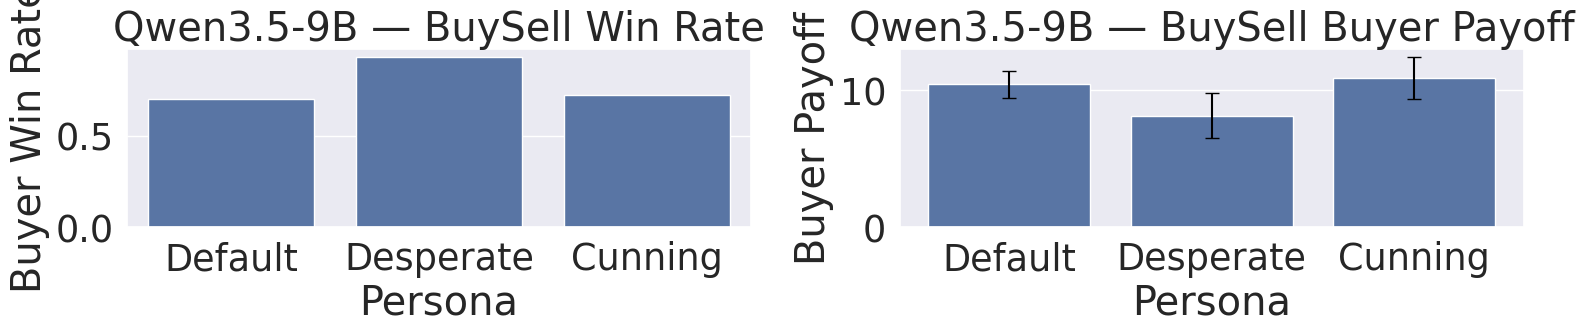

In [126]:
#  Per-model persona plots for BuySell 

for model_name in AGENTS_CLEAN_NAMES:
    sub = bs[bs["model_1"] == model_name].copy()
    if len(sub) == 0:
        print(f"No data for {model_name}, skipping.")
        continue

    agg = buysell_persona_aggregation(sub)
    agg = agg.set_index("social_2").reindex(PERSONAS)

    fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
    fig.tight_layout()

    # Win Rate (buyer/P2 perspective)
    sns.barplot(data=agg.reset_index(), x="social_2", y="win_2_mean",
                order=PERSONAS, ax=axs[0])
    axs[0].set_xlabel("Persona")
    axs[0].set_ylabel("Buyer Win Rate")
    axs[0].set_title(f"{model_name} — BuySell Win Rate")

    # Buyer Payoff
    sns.barplot(data=agg.reset_index(), x="social_2", y="outcome_2_mean",
                order=PERSONAS, ax=axs[1])
    axs[1].errorbar(x=range(len(PERSONAS)),
                    y=agg["outcome_2_mean"].values,
                    yerr=agg["outcome_2_sem"].values,
                    fmt='none', c='black', capsize=5)
    axs[1].set_xlabel("Persona")
    axs[1].set_ylabel("Buyer Payoff")
    axs[1].set_title(f"{model_name} — BuySell Buyer Payoff")

    fig.tight_layout()
    #fig.savefig(f"../../figures/{FIGURE_PRENAME}_buysell_{model_name}.pdf",
                #bbox_inches='tight')
    plt.show()

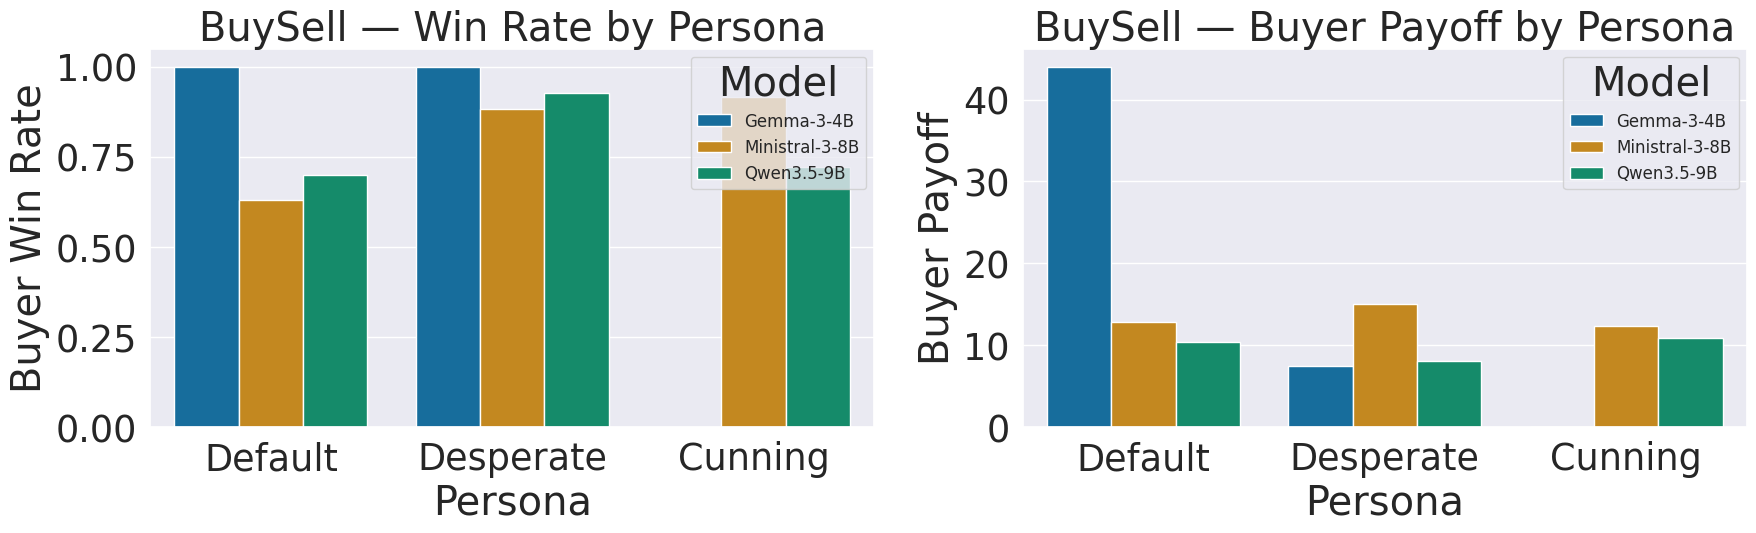

In [127]:
#  Combined BuySell plot 

agg_all = buysell_persona_aggregation(bs)

fig, axs = plt.subplots(figsize=(18, 6), ncols=2)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="win_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[0], palette="colorblind")
axs[0].set_xlabel("Persona")
axs[0].set_ylabel("Buyer Win Rate")
axs[0].set_title("BuySell — Win Rate by Persona")
axs[0].legend(title="Model", fontsize=12)

sns.barplot(data=agg_all.reset_index(), x="social_2", y="outcome_2_mean",
            hue="model_1", order=PERSONAS, ax=axs[1], palette="colorblind")
axs[1].set_xlabel("Persona")
axs[1].set_ylabel("Buyer Payoff")
axs[1].set_title("BuySell — Buyer Payoff by Persona")
axs[1].legend(title="Model", fontsize=12)

fig.tight_layout()
#fig.savefig(f"../../figures/{FIGURE_PRENAME}_buysell_combined.pdf",
            #bbox_inches='tight')
plt.show()

---
## Game Completion Rates by Persona

Important sanity check: do personas cause more games to break?

In [128]:
def load_completion_stats_with_persona(log_dirs):
    """Count total vs completed games, including persona info."""
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                settings = data["game_state"][0].get("settings", {})
                behaviours = settings.get("player_social_behaviour", ["", ""])
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "social_2": behaviours[1] if len(behaviours) > 1 else "",
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": LOGS_ROOT_TRADING,
    "Ultimatum": LOGS_ROOT_ULTIMATUM,
    "BuySell": LOGS_ROOT_BUYSELL,
}

df_comp = load_completion_stats_with_persona(log_dirs)
df_comp["model_1"] = df_comp["model_1"].replace(rename_dict)

# Map behaviours to persona names (merge all game-specific dicts)
all_behaviour_map = {}
all_behaviour_map.update(BEHAVIOUR_TO_NAME_TRADING)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_ULTIMATUM)
all_behaviour_map.update(BEHAVIOUR_TO_NAME_BUYSELL)
df_comp["persona"] = df_comp["social_2"].replace(all_behaviour_map)

comp_agg = df_comp.groupby(["game", "model_1", "persona"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
comp_agg["pct"] = comp_agg["completed"] / comp_agg["total"] * 100

print(comp_agg.to_string(index=False))

     game        model_1   persona  total  completed        pct
  BuySell     Gemma-3-4B   Cunning     30          4  13.333333
  BuySell     Gemma-3-4B   Default     30          5  16.666667
  BuySell     Gemma-3-4B Desperate     30          2   6.666667
  BuySell   Llama-3.1-8B   Cunning     30          0   0.000000
  BuySell   Llama-3.1-8B   Default     30          0   0.000000
  BuySell   Llama-3.1-8B Desperate     30          0   0.000000
  BuySell Ministral-3-8B   Cunning     30         23  76.666667
  BuySell Ministral-3-8B   Default     30         23  76.666667
  BuySell Ministral-3-8B Desperate     30         22  73.333333
  BuySell     Qwen3.5-9B   Cunning     30         27  90.000000
  BuySell     Qwen3.5-9B   Default     30         30 100.000000
  BuySell     Qwen3.5-9B Desperate     30         29  96.666667
  Trading     Qwen3.5-9B   Cunning     30          4  13.333333
  Trading     Qwen3.5-9B   Default     30          5  16.666667
  Trading     Qwen3.5-9B Desperate     3

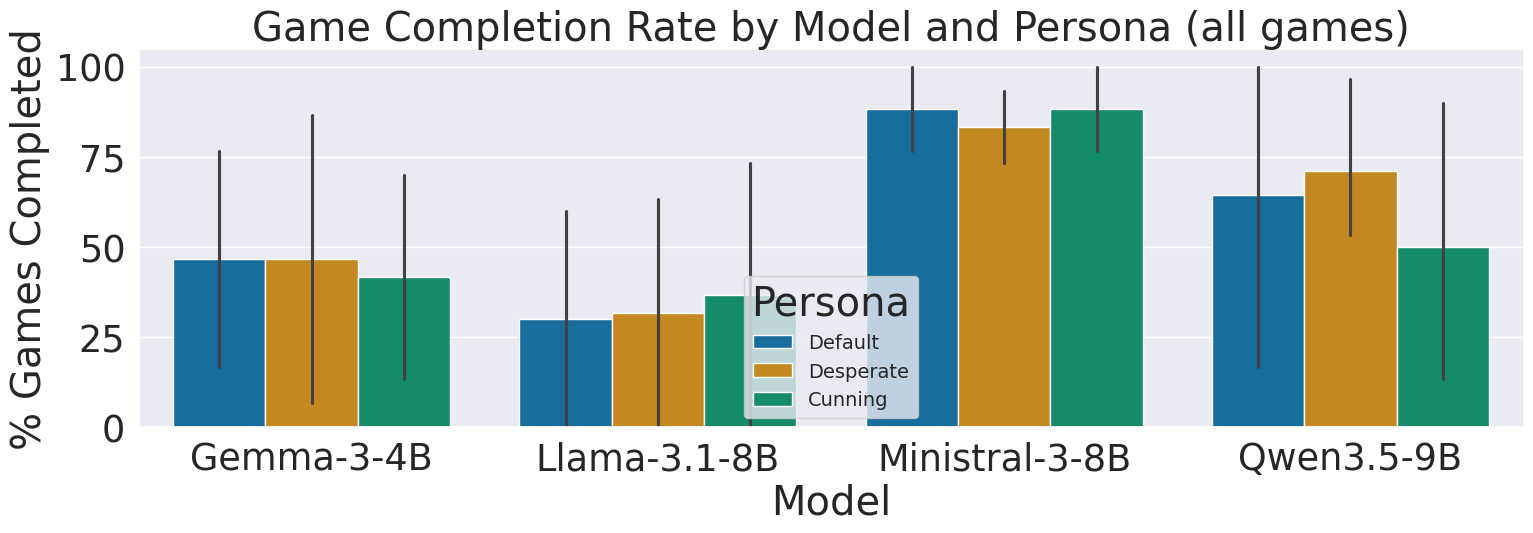

In [129]:
#  Completion rate bar plot 

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=comp_agg, x="model_1", y="pct",
            hue="persona", hue_order=PERSONAS,
            palette="colorblind", ax=ax)
ax.set_ylabel("% Games Completed")
ax.set_xlabel("Model")
ax.set_title("Game Completion Rate by Model and Persona (all games)")
ax.set_ylim(0, 105)
ax.legend(title="Persona", fontsize=14)
fig.tight_layout()
#fig.savefig(f"../../figures/{FIGURE_PRENAME}_completion_by_persona.pdf",
            #bbox_inches='tight')
plt.show()